In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [2]:
news = pd.read_csv("Data/news_articles.csv" ,index_col=0)
articles = news['content']
en_stopword = stopwords.words('english')

In [3]:
articles = articles.apply(lambda article : [word.lower() for word in article.split() if word not in en_stopword])
articles = articles.apply(lambda article : ' '.join([re.sub(r'[^\s\w]', '', word) for word in article] ))

In [4]:
articles = articles.apply(lambda article : word_tokenize(article)  )

In [5]:
ps = PorterStemmer()
articles = articles.apply(lambda tokens : [ps.stem(token) for token in tokens] )

In [6]:
articles.head()

id
25626    [dr, frank, sack, professor, nutrit, harvard, ...
19551    [south, carolina, win, duke, surpris, fan, in,...
25221    [want, get, brief, email, here, good, even, he...
18026    [banjul, gambia, a, week, inaugur, anoth, coun...
21063    [the, biggest, book, summer, isnt, blockbust, ...
Name: content, dtype: object

In [7]:
import gensim
import gensim.corpora as corpora

dictionary = corpora.Dictionary(articles)
print(dictionary)
#print(dictionary.token2id)
doc_term = [dictionary.doc2bow(text) for text in articles]
#print(doc_term)

Dictionary<8795 unique tokens: ['10', '100', '108', '15', '155']...>


In [8]:
num_topic = 2
lda_model = gensim.models.LdaModel(corpus=doc_term, id2word=dictionary, num_topics=num_topic)
lda_model.print_topics(num_topics=num_topic, num_words=5)
#lda_model.get_document_topics(doc_term[1])

[(0, '0.015*"said" + 0.014*"mr" + 0.010*"the" + 0.006*"i" + 0.006*"trump"'),
 (1, '0.018*"mr" + 0.012*"said" + 0.010*"the" + 0.008*"i" + 0.006*"it"')]

In [9]:
from gensim.models import LsiModel

lsa_model = LsiModel(corpus=doc_term, id2word=dictionary, num_topics=num_topic)
lsa_model.print_topics(num_topics=num_topic, num_words=5)


[(0, '0.520*"mr" + 0.386*"said" + 0.266*"i" + 0.248*"the" + 0.161*"it"'),
 (1, '0.569*"i" + -0.550*"mr" + -0.239*"trump" + 0.165*"it" + 0.105*"show"')]

Processing 2 topics
Processing 3 topics
Processing 4 topics
Processing 5 topics


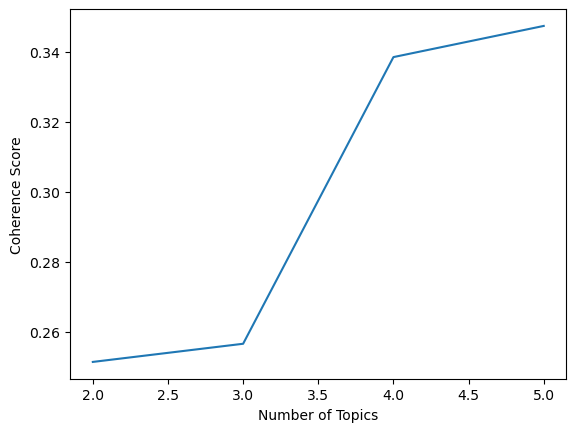

In [10]:
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

coherence_value = []
model_list = []

min_topic = 1
max_topic = 11


for num_topic_i in range(2, 6):   # small range first
    print(f"Processing {num_topic_i} topics")

    model = LsiModel(corpus=doc_term, id2word=dictionary, num_topics=num_topic_i)
    model_list.append(model)
    coherence_model = CoherenceModel(
        model=model,
        texts=articles[:500],   # sample for speed
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_value.append(coherence_model.get_coherence())

plt.plot(range(2, 6), coherence_value)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.show()